<a href="https://colab.research.google.com/github/AChierici84/ProfessionAI/blob/main/Classificazione_Frutti_esotici.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Classificazione di frutti esotici

TropicTaste Inc., leader nella distribuzione di frutti esotici, intende migliorare l'efficienza e l'accuratezza nel processo di classificazione dei frutti. L'obiettivo è sviluppare un modello di machine learning in grado di predire il tipo di frutto basandosi su caratteristiche numeriche.

L'attuale processo di classificazione dei frutti esotici è manuale e soggetto a errori, risultando inefficiente e dispendioso in termini di risorse. La necessità di un sistema automatizzato e preciso è cruciale per ottimizzare le operazioni aziendali e mantenere alti standard qualitativi.

Implementando un modello di classificazione automatizzato, TropicTaste Inc. potrà:

*   **Migliorare l'Efficienza Operativa**: Automatizzare la classificazione ridurrà il tempo e le risorse necessarie, aumentando la produttività.
*   **Ridurre gli Errori Umani**: Un modello di machine learning minimizzerà gli errori di classificazione, garantendo una maggiore precisione.
*   **Ottimizzare l'Inventario**: Una classificazione accurata permetterà una migliore gestione dell'inventario, assicurando condizioni ottimali di conservazione per ogni tipo di frutto.
*   **Aumentare la Soddisfazione del Cliente**: Una corretta identificazione e classificazione dei frutti contribuirà a mantenere elevati standard di qualità, migliorando la soddisfazione dei clienti.

**Dettagli del Progetto:**

1.   **Dataset**: Utilizzo di un dataset contenente varie caratteristiche numeriche di diversi frutti esotici.
2.   **Algoritmo**: Implementazione dell'algoritmo K-Nearest Neighbors (KNN) per la classificazione.
3.   **Output**: Il modello deve predire correttamente il tipo di frutto basandosi sui dati forniti.

**Requisiti del progetto:**


1.   **Preparazione del Dataset:**
*   Caricamento e preprocessamento dei dati sui frutti esotici.
*   Gestione di eventuali valori mancanti, normalizzazione e scalatura dei dati.
2.   **Implementazione del Modello KNN:**
*   Sviluppo e addestramento del modello KNN.
*   Ottimizzazione dei parametri per migliorare l'accuratezza predittiva.
3.   **Valutazione delle Performance:**
*   Utilizzo di tecniche di validazione incrociata per valutare la capacità di generalizzazione del modello.
*   Calcolo delle metriche di performance, come l'accuratezza e l'errore di classificazione.
4.   **Visualizzazione dei Risultati:**
*   Creazione di grafici per visualizzare e confrontare le performance del modello.
*   Analisi e interpretazione dei risultati per identificare eventuali aree di miglioramento.

##Variabili del Dataset

Il dataset è scaricabile da qui: [https://proai-datasets.s3.eu-west-3.amazonaws.com/fruits.csv](https://proai-datasets.s3.eu-west-3.amazonaws.com/fruits.csv)

Contiene le seguenti variabili:

1.   **Frutto**: Il tipo di frutto. Questa è la variabile di destinazione (target) che vogliamo prevedere.
2.   **Peso (g)**: Il peso del frutto in grammi. Variabile continua.
3.   **Diametro medio (mm)**: Il diametro medio del frutto in millimetri. Variabile continua.
4.   **Lunghezza media (mm)**: La lunghezza media del frutto in millimetri. Variabile continua.
5.   **Durezza buccia (1-10)**: La durezza della buccia del frutto su una scala da 1 a 10. Variabile continua.
6.   **Dolcezza (1-10)**: La dolcezza del frutto su una scala da 1 a 10. Variabile continua.

Ricorda di eseguire una corretta analisi esplorativa del dataset prima di procedere con il modello. Ricordati anche di applicare il corretto preprocessing ai dati e di misurare le performance del modello secondo le metriche che ritieni più utili.

Accompagna ogni passo dell’analisi con grafici appropriati e commenta adeguatamente ogni passaggio, estraendo degli insight utili all’analisi e alla comprensione dell’informazione trasmessa dal dato.









In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib # per salvare il modello
from sklearn.preprocessing import MinMaxScaler, label_binarize, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, log_loss, f1_score, balanced_accuracy_score, RocCurveDisplay
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import PrecisionRecallDisplay, precision_recall_curve, average_precision_score
from sklearn.model_selection import train_test_split,learning_curve, validation_curve, cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
#type Hinting
from dataclasses import dataclass

In [ ]:
@dataclass
class ClassificationMetrics:
    accuracy: float
    log_loss: float
    balanced_accuracy: float
    f1_score: float

@dataclass
class EvalResult:
    metrics_train: ClassificationMetrics
    metrics_test: ClassificationMetrics


def evaluate(model,train_set,test_set)-> EvalResult:
  """
  Funzione che valuta un modello stampando LOG_LOSS e ACCURACY
  Input:
      model: modello di classificazione
      train_set: tuple (X_train, y_train)
      test_set: tuple (X_test, y_test)
  Output:
      EvalResult: oggetto contenente le metriche di valutazione
  """

  X_train, y_train = train_set
  X_test, y_test = test_set

  result = EvalResult(None, None)

  y_pred_train= model.predict(X_train)
  y_pred_test= model.predict(X_test)

  accuracy_train=accuracy_score(y_train, y_pred_train)
  accuracy_test=accuracy_score(y_test, y_pred_test)

  f1_score_train=f1_score(y_train, y_pred_train, average='macro')  #macro → se vuoi trattare tutte le classi allo stesso modo (anche quelle rare)
  f1_score_test=f1_score(y_test, y_pred_test, average='macro')     #weighted → se vuoi tenere conto del bilanciamento delle classi
                                                                   #micro → se vuoi una visione globale (molto usato per classificazioni multilabel)
                                                                   #none → se vuoi vedere le metriche classe per classe

  balanced_accuracy_score_train=balanced_accuracy_score(y_train, y_pred_train)
  balanced_accuracy_score_test=balanced_accuracy_score(y_test, y_pred_test)

  if hasattr(model, "predict_proba"):
    y_proba_train= model.predict_proba(X_train)
    y_proba_test= model.predict_proba(X_test)
    log_loss_train=log_loss(y_train, y_proba_train)
    log_loss_test=log_loss(y_test, y_proba_test)
  else:
    log_loss_train=None
    log_loss_test=None

  result.metrics_train = ClassificationMetrics(accuracy_train, log_loss_train,balanced_accuracy_score_train,f1_score_train)
  result.metrics_test = ClassificationMetrics(accuracy_test, log_loss_test, balanced_accuracy_score_test,f1_score_test)

  return result


##Analisi Esplorativa dei Dati (EDA)

In [ ]:
BASE_URL="https://proai-datasets.s3.eu-west-3.amazonaws.com/"
RANDOM_STATE=0
N_SPLITS=5

# disattiva la notazione scientifica
np.set_printoptions(suppress=True, precision=6)

In [ ]:
df=pd.read_csv(BASE_URL+ "fruits.csv")
df.head()

,Frutto,Peso (g),Diametro medio (mm),Lunghezza media (mm),Durezza buccia (1-10),Dolcezza (1-10)
0,Mela,86.40,89.68,8.69,9.61,2.41
1,Mela,77.58,73.45,6.49,7.20,3.87
2,Mela,81.95,81.66,6.40,9.09,2.88
3,Mela,66.33,36.71,6.78,8.21,2.55
4,Mela,56.73,75.69,5.78,9.15,3.88


Classi del modello e numerosità

In [ ]:
df["Frutto"].value_counts()

,count
Frutto,
Mela,100
Banana,100
Arancia,100
Uva,100
Kiwi,100


Le 5 classi sono bilanciate , abbiamo uguale numero di sample per ogni classe, per un totale di 500 record.

Eliminiamo la colonna **'Frutto'** che costituisce il target del modello e studio le feature rimanenti.

In [ ]:
df_features=df.drop("Frutto", axis=1)
df_features.head()

,Peso (g),Diametro medio (mm),Lunghezza media (mm),Durezza buccia (1-10),Dolcezza (1-10)
0,86.40,89.68,8.69,9.61,2.41
1,77.58,73.45,6.49,7.20,3.87
2,81.95,81.66,6.40,9.09,2.88
3,66.33,36.71,6.78,8.21,2.55
4,56.73,75.69,5.78,9.15,3.88


Abbiamo 500 sample, tutti dati numerici float.

In [ ]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Peso (g)               500 non-null    float64
 1   Diametro medio (mm)    500 non-null    float64
 2   Lunghezza media (mm)   500 non-null    float64
 3   Durezza buccia (1-10)  500 non-null    float64
 4   Dolcezza (1-10)        500 non-null    float64
dtypes: float64(5)
memory usage: 19.7 KB


Studio la media, i valori massimi e i minimi.

In [ ]:
df_features.describe()

,Peso (g),Diametro medio (mm),Lunghezza media (mm),Durezza buccia (1-10),Dolcezza (1-10)
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,47.313440,86.573100,5.298620,7.437640,3.593220
std,26.768797,64.293403,2.641993,1.812548,1.264899
min,8.570000,7.530000,1.150000,3.070000,1.250000
25%,24.797500,50.510000,2.672500,6.152500,2.570000
50%,42.380000,70.450000,5.670000,7.340000,3.535000
75%,68.080000,88.852500,7.455000,8.615000,4.465000
max,111.210000,299.890000,11.140000,13.720000,6.950000


## Preprocessing


Tutte le feature sono quantitative, non sono necessarie operazioni di Encoding.

Contrariamente a quanto indicato la massima del grado della durezza della buccia sembra essere 13.72. Questo valore probabilmente è dovuto ad un valore preso erroneamente procediamo a rimappare a 10 i valori i durezza che esulano dall'intervallo base.


In [ ]:
out_of_range = df[df['Durezza buccia (1-10)'] > 10]
print("Numero valori > 10:", len(out_of_range))

Numero valori > 10: 40


Cerchiamo di valutare se potrebbe trattarsi di outlier.

I valori sono troppi per essere esclusi, potrerebbero allo sbilanciamento di alcune classi, soprattutto quella dell'uva. In alternativa possiamo considerare:
la **correzione** ossia sostituire valori >10 con 10

In [ ]:
condition=df_features["Durezza buccia (1-10)"]>10
df_features.loc[condition,"Durezza buccia (1-10)"]=10

df_features.describe()

,Peso (g),Diametro medio (mm),Lunghezza media (mm),Durezza buccia (1-10),Dolcezza (1-10)
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,47.313440,86.573100,5.298620,7.354140,3.593220
std,26.768797,64.293403,2.641993,1.643219,1.264899
min,8.570000,7.530000,1.150000,3.070000,1.250000
25%,24.797500,50.510000,2.672500,6.152500,2.570000
50%,42.380000,70.450000,5.670000,7.340000,3.535000
75%,68.080000,88.852500,7.455000,8.615000,4.465000
max,111.210000,299.890000,11.140000,10.000000,6.950000


Se non avessimo avuto Range così netti già previsti dal sistema avremmo dovuto utilizzare una trasformazione come il Robust scaler che attua una scalatura su mediana e IQR.

IQR = Interquartile Range = differenza tra il 75° percentile e il 25° percentile di una distribuzione.

IQR=Q3−Q1

Dove:

Q1 (1° quartile, 25%) → valore sotto il quale cade il 25% dei dati

Q3 (3° quartile, 75%) → valore sotto il quale cade il 75% dei dati

Quindi l’IQR misura l’intervallo centrale dei dati, cioè dove cade la metà centrale della distribuzione.

###Dati Mancanti
Valutiamo la numerosità dei dati e la presenza di dati mancanti.

In [ ]:
df_features.count()

,0
Peso (g),500
Diametro medio (mm),500
Lunghezza media (mm),500
Durezza buccia (1-10),500
Dolcezza (1-10),500


In [ ]:
df_features.isna().sum()

,0
Peso (g),0
Diametro medio (mm),0
Lunghezza media (mm),0
Durezza buccia (1-10),0
Dolcezza (1-10),0


Non sono stati riscontrati dati mancanti.

###Matrice di correlazione

Analizziamo la matrice di correlazione per valutare se ci sono feature correlate tra loro.

<Axes: >

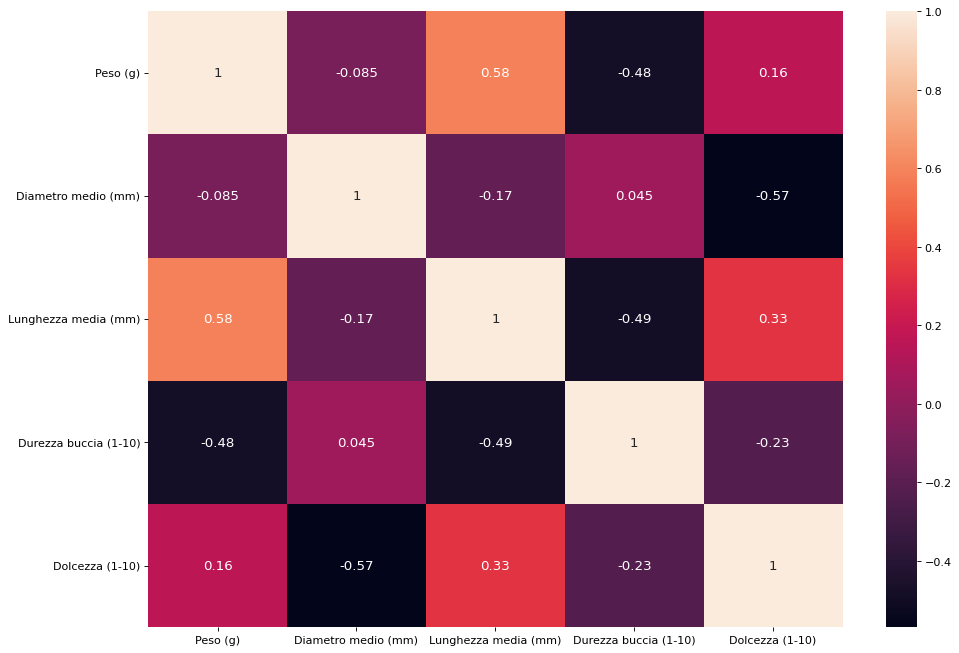

In [ ]:
plt.figure(figsize=(14, 10), dpi=80)

sns.heatmap(df_features.corr(),
            annot=True,
            xticklabels=df_features.columns,
            yticklabels=df_features.columns,
            annot_kws={'size':12}
            )

Il peso sembra essere mediamente correlato alla lunghezza e inversamente alla durezza. Allo stesso modo sembrano inversamente correlati il diametro e la dolcezza. La durezza della buccia si può rapportare al peso o al diametro medio,
non chè alla stessa lunghezza. Lunghezza e diametro invece non sembrano molto correlate tra loro. Non sembrano esserci feature da scartare.

Potremmo anche visualizzare la distribuzione delle feature in base alla classe.

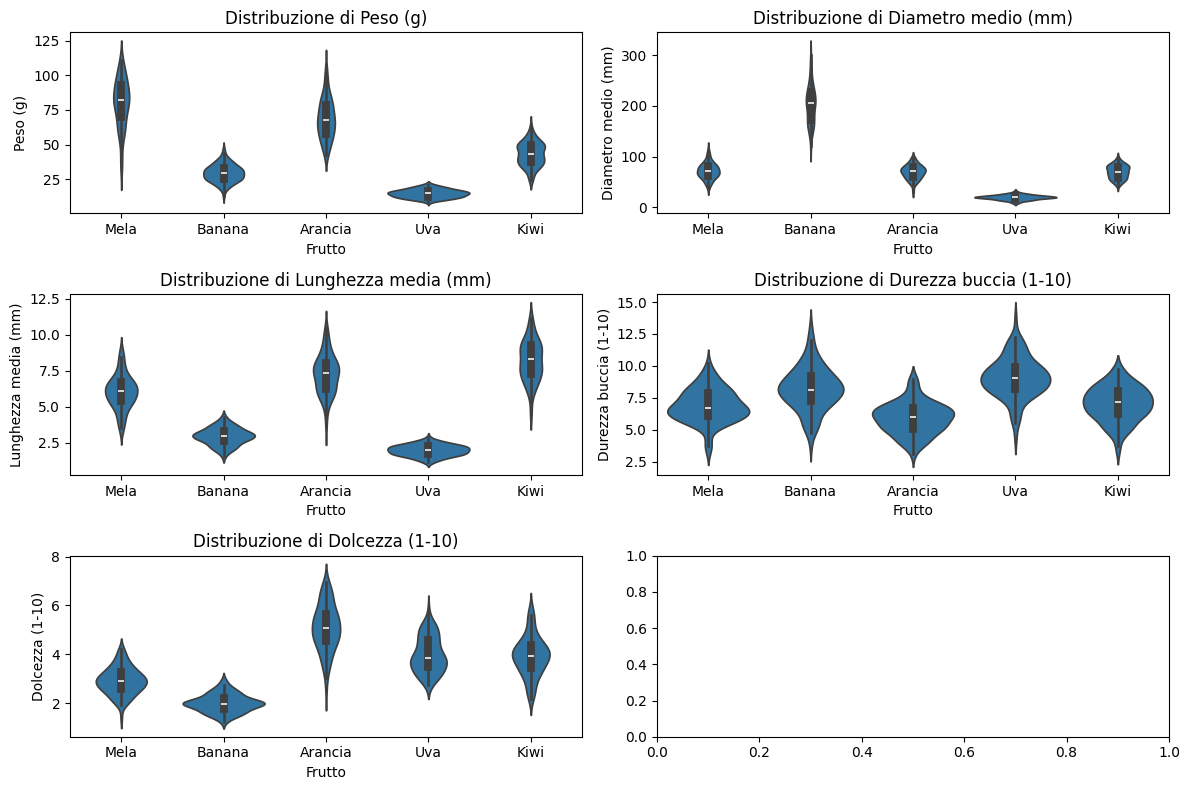

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8))

axes = axes.flatten()

for i, col in enumerate(df.columns[1:]):
    sns.violinplot(
        data=df,
        x="Frutto",
        y=col,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribuzione di {col}")

plt.tight_layout()
plt.show()

Per Peso, diametro e lunghezza media sono distintamente visibili valori simili tra loro per ogni classe, abbastanza condensati. Per quanto riguarda la durezza della buccia la distribuzione è variegata, ma sono visibili valori confrontabili per ogni frutto. La dolcezza si suddivide in due grandi nuvole facendo presupporre che mela e banana siano più dolci generalmente rispetto a kiwi, arancia e uva.  In ogni caso anche questo risulta un buon indicatore per aiutare a classificare la frutta.

###Normalizzazione/scalatura dei dati

I dati sono riportati in diverse unità di misura.

*   g per il peso
*   mm per lunghezza e diametro medio
*   grado da 1 a 10 per Durezza e Dolcezza.

Per prima cosa devo riportare il grado di Durezza e Dolcezza in una scala da 0 a 1 mentre attualmente vanno da 1 a 10.
Anche gli altri valori hanno scale differenti, devono essere portati tutti nello stesso range per facilitare l'apprendimento del modello.
Effettuerò la normalizzazione a seguito della divisione in train e test set.




Procediamo all'estrazione delle features.

In [ ]:
X=df_features.values
y=df["Frutto"].values

Dividiamo train e test set.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE,stratify=y) #l’opzione stratify=y fa sì che il train set e il test set mantengano la stessa distribuzione delle classi che avevi nel dataset originale.

Applico sulle feature la normalizzazione di modo che siano tutte nello stesso range, pertanto più facilmente confrontabili tra loro.

## Model selection
Prima di addestrare il modello dobbiamo valutare il numero di neighbors (K) che ci permette di massimizzare le perfermance sul test set senza incorrere nella OVERFITTING.

Ci baseremo sulle metriche di:


*   **Accuracy**: La proporzione di predizioni corrette sul totale delle osservazioni.

Proviamo ad addestrare diversi modelli per numero di "Vicini" (K) differente e ne valutiamo le perfermormance.



In [ ]:
ks=[1,3,5,7,9,11,15,19,23,29]
weights=["uniform", "distance"]
metric=["minkowski"]
p=[1,2]

# Definisci la pipeline: scaler -> classificatore
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier())
])


# Griglia dei parametri (nota il prefisso "knn__")
param_grid = {
    'knn__n_neighbors': ks,
    'knn__weights': weights,
    'knn__metric': metric,
    'knn__p': p
}


# Configura la Grid Search con cross-validation
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,              # 5-fold cross-validation
    scoring='accuracy' # metrica di valutazione
)

# Esegui la ricerca
grid_search.fit(X_train, y_train)

print("Miglior n_neighbors:", grid_search.best_params_['knn__n_neighbors'])
print("Miglior accuracy CV:", grid_search.best_score_)
print("Accuracy su test:", grid_search.best_estimator_.score(X_test, y_test))

Miglior n_neighbors: 23
Miglior accuracy CV: 0.9285714285714285
Accuracy su test: 0.9066666666666666


Con k=11 otteniamo un buon risultato di 0.928 con 0.9 sul test set.

Salvo il modello migliore.

In [ ]:
best_knn = grid_search.best_estimator_
best_knn

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('knn', KNeighborsClassifier(n_neighbors=23, p=1))])

Valutiamo ora le prestazioni del modello.

In [ ]:
best_knn.score(X_test,y_test)

0.9066666666666666

Calcolo le metriche precise per il modello addestrato.

In [ ]:
result=evaluate(best_knn,(X_train, y_train),(X_test, y_test))

print(f" --- TRAIN ---")
print(f" accuracy: {result.metrics_train.accuracy:.3f}")
print(f" log_loss: {result.metrics_train.log_loss:.3f}")
print(f" balanced_accuracy_score: {result.metrics_train.balanced_accuracy:.3f}")
print(f" f1_score: {result.metrics_train.f1_score:.3f}")
print(f"\n --- TEST ---")
print(f" accuracy: {result.metrics_test.accuracy:.3f}")
print(f" log_loss: {result.metrics_test.log_loss:.3f}")
print(f" balanced_accuracy_score: {result.metrics_test.balanced_accuracy:.3f}")
print(f" f1_score: {result.metrics_test.f1_score:.3f}")

 --- TRAIN ---
 accuracy: 0.929
 log_loss: 0.200
 balanced_accuracy_score: 0.929
 f1_score: 0.928

 --- TEST ---
 accuracy: 0.907
 log_loss: 0.198
 balanced_accuracy_score: 0.907
 f1_score: 0.906


Stampiamo anche il report di classificazione e la matrice di confusione.

In [ ]:
print(classification_report(y_test, best_knn.predict(X_test)))

              precision    recall  f1-score   support

     Arancia       0.85      0.77      0.81        30
      Banana       1.00      1.00      1.00        30
        Kiwi       0.79      0.87      0.83        30
        Mela       0.90      0.90      0.90        30
         Uva       1.00      1.00      1.00        30

    accuracy                           0.91       150
   macro avg       0.91      0.91      0.91       150
weighted avg       0.91      0.91      0.91       150



In [ ]:
y_pred_test=best_knn.predict(X_test)
cm=confusion_matrix(y_test, best_knn.predict(X_test))
print(cm)

[[23  0  5  2  0]
 [ 0 30  0  0  0]
 [ 3  0 26  1  0]
 [ 1  0  2 27  0]
 [ 0  0  0  0 30]]


Per vedere meglio le %  procediamo con la normalizzazione: i valori (0.00 / 1.00) rappresentano la percentuale di campioni classificati correttamente o erroneamente

In [ ]:
# Calcolo della confusion matrix normalizzata
cm_norm = confusion_matrix(y_test, y_pred_test, normalize='true')

print(cm_norm)  # matrice normalizzata (valori da 0 a 1)

[[0.766667 0.       0.166667 0.066667 0.      ]
 [0.       1.       0.       0.       0.      ]
 [0.1      0.       0.866667 0.033333 0.      ]
 [0.033333 0.       0.066667 0.9      0.      ]
 [0.       0.       0.       0.       1.      ]]


Possiamo notare che le classi che danno il miglior risultato sono uva e banana, seguite dalla mela. Un po' più basse sono le metriche riguardanti kiwi e arancia con f1-score (media armonica di precision e recall) intorno a 0,87-0,87.
Valutando poi la matrice di confusione possiamo notale come i frutti più difficili da distinguere per il modello sono  Arancia , Kiwi e Mela che in effetti sono più simili tra loro per forma, dimensione (diametro e lunghezza).

##Valutazione e analisi degli errori

###Cross validation

Verifico quanto bene il modello riesce a generalizzare su dati nuovi mediante tecnica di validazione incrociata.


In [ ]:
#calcolo la cross validation
scores = cross_val_score(pipeline, X, y, cv=N_SPLITS)

print("Accuracy sui set:", scores)
print("Accuracy media:", scores.mean())

Accuracy sui set: [0.9  0.94 0.94 0.91 0.89]
Accuracy media: 0.916


Valutiamo che l'accuracy è equiparabile a quella riscontrata. Quindi il modello risultante col valore di k scelto riesce a generalizzare bene nuovi dati.

###Matrice di confusione

Mostriamo in modalità grafica la matrice di confusione per  visualizzare meglio le classi più problematiche (arancia, mela e kiwi)

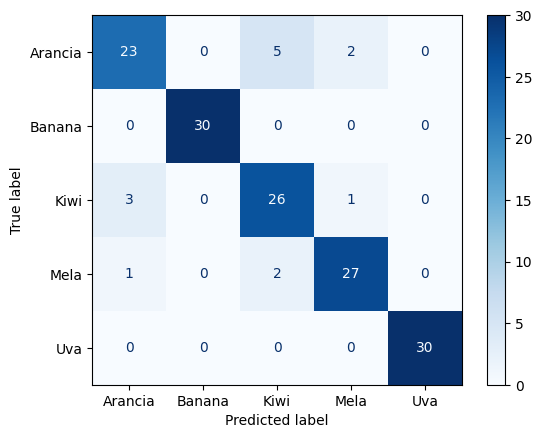

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=best_knn.classes_)
disp.plot(cmap="Blues")
plt.show()

Ovviamente se pensiamo alla forma e alla dimensione media dei frutti non stupisce del tutto che queste siano le classi in cui il modello fatica di più. L'uva è molto più piccola e la banana ha una forma , stretta e allungata, completamente diversa.

In [ ]:
# Calcolo della confusion matrix normalizzata
cm = confusion_matrix(y_test, y_pred_test, normalize='true')

print(cm)  # matrice normalizzata (valori da 0 a 1)

[[0.766667 0.       0.166667 0.066667 0.      ]
 [0.       1.       0.       0.       0.      ]
 [0.1      0.       0.866667 0.033333 0.      ]
 [0.033333 0.       0.066667 0.9      0.      ]
 [0.       0.       0.       0.       1.      ]]


###Classification report

La difficoltà su queste classi è visibile anche dal report di classificazione.



In [ ]:
report_dict = classification_report(y_test, best_knn.predict(X_test), output_dict=True)

# Estraggo solo le classi
classes = [k for k in report_dict.keys() if k not in ['accuracy','macro avg','weighted avg']]
data = {cls: report_dict[cls] for cls in classes}

# Trasformo in DataFrame
df_classes = pd.DataFrame(data).T[['precision','recall','f1-score']]
df_classes

,precision,recall,f1-score
Arancia,0.851852,0.766667,0.807018
Banana,1.000000,1.000000,1.000000
Kiwi,0.787879,0.866667,0.825397
Mela,0.900000,0.900000,0.900000
Uva,1.000000,1.000000,1.000000


Dal dataframe ricavo il grafico a barre sulle classi:

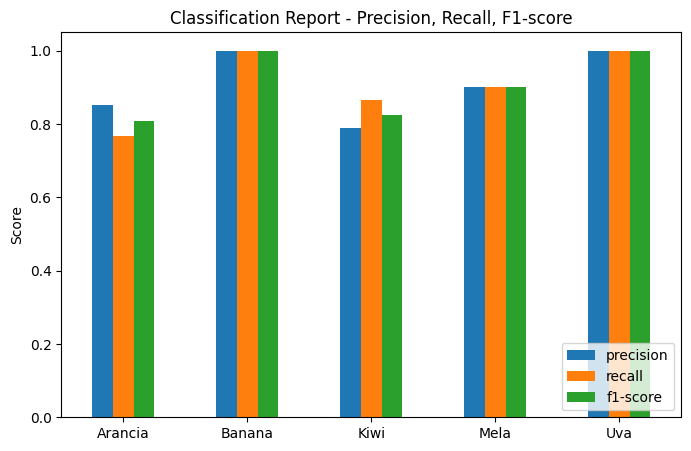

In [ ]:
# Grafico a barre
df_classes.plot(kind='bar', figsize=(8,5))
plt.title("Classification Report - Precision, Recall, F1-score")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

Uva e banana sono perfettamente riconosciute mentre mela, kiwi e arancia hanno valori più bassi di precision e recall. Il frutto che ha la Recall più bassa e quindi viene spesso scambiato (per arancia o kiwi) è la mela.

### ROC-AUC One-vs-Rest (OvR)



Ogni curva ROC rappresenta una classe vs tutte le altre (One-vs-Rest).

Sull'asse x il **False Positive Rate (FPR)**  rappresenta la percentuale di campioni non appartenenti alla classe classificati erroneamente come appartenenti.

sull'asse Y il **True Positive Rate (TPR)** identifica la percentuale di campioni veramente della classe classificati correttamente

Quindi tanto più una curva è vicina all’angolo in alto a sinistra, quanto più avremo un ottima performance (TPR alta, FPR bassa).

**AUC (Area Under the Curve)**: misura sintetica della performance della classe

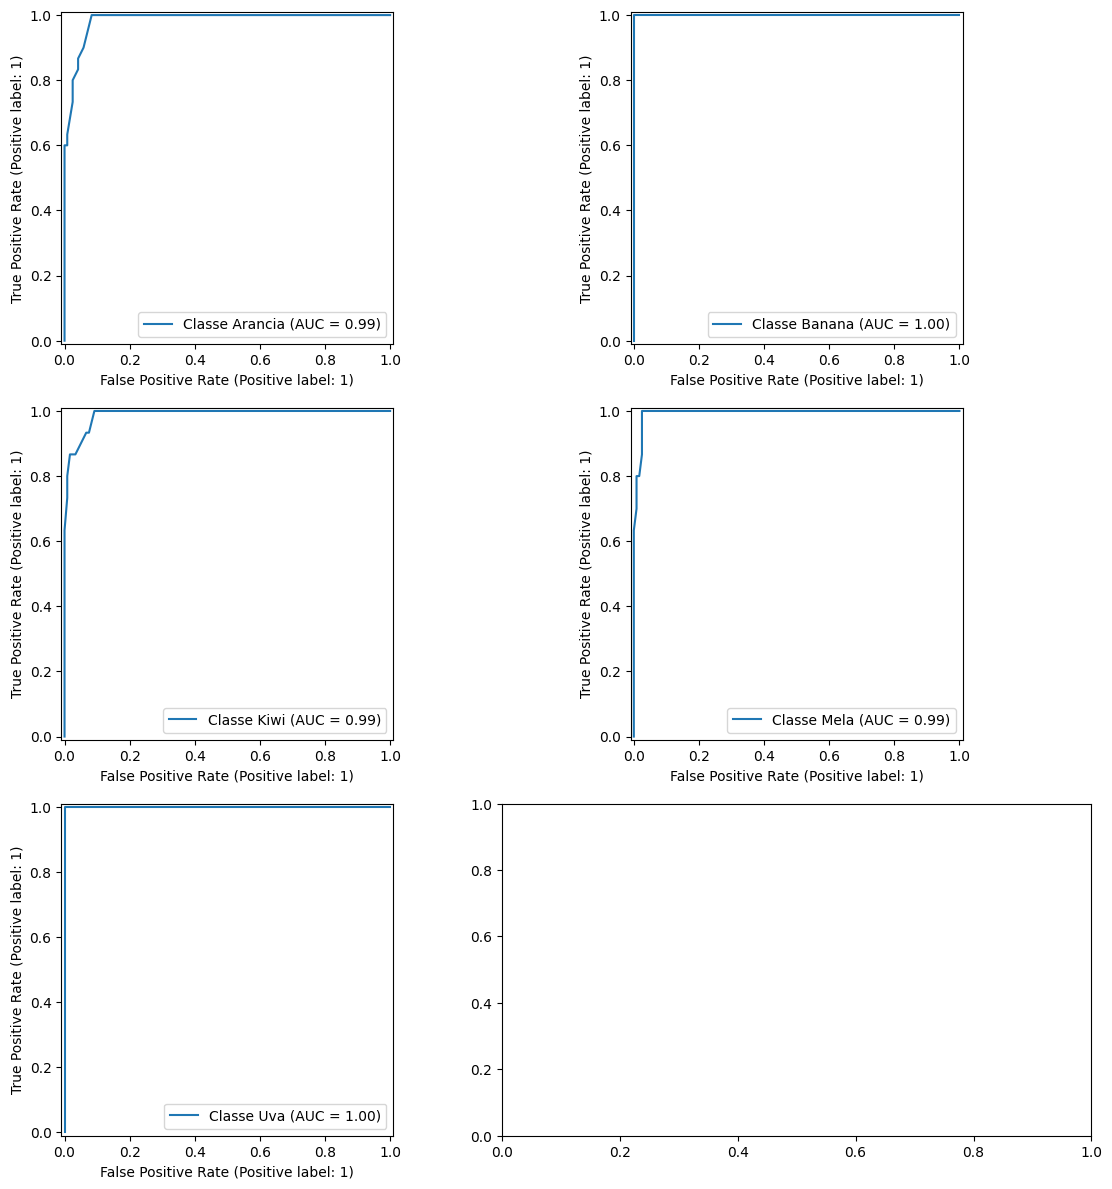

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

axes = axes.flatten()

# Trasforma y in binario per ogni classe
y_test_bin = label_binarize(y_test, classes=best_knn.classes_)
n_classes = y_test_bin.shape[1]

y_score = best_knn.predict_proba(X_test)  # shape = (n_samples, n_classes)

for i in range(n_classes):
    if y_test_bin[:, i].sum() > 0:
        RocCurveDisplay.from_predictions(y_test_bin[:, i], y_score[:, i], name=f"Classe {best_knn.classes_[i]}", ax=axes[i])

plt.tight_layout()
plt.show()

In questo caso Uva e Banana sono praticamente adese agli assi. Le altre categorie di frutta si scostano leggermente.


### Curve Precision-Recall (PR) - OVR

Ogni curva rappresenta anche in questo caso una classe vs tutte le altre (One-vs-Rest).

Utilizziamo la binarizzazione e le previsioni precedentemente calcolate.

Sull'asse X abbiamo la **Recall** (Sensibilità): percentuale di campioni della classe catturati dal modello.

Sull'asse Y invece la **Precision**: percentuale di campioni predetti come classe corretta.

Una curva alta e a destra indica un modello molto preciso e sensibile.

**AP (Average Precision)** è simile all’**AUC**: più si avvicina a 1, meglio il modello performa.



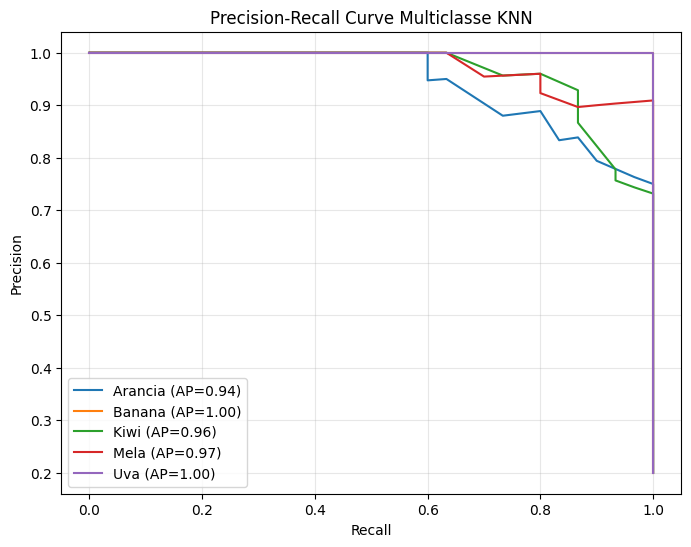

In [ ]:
plt.figure(figsize=(8, 6))

for i, classe in enumerate(best_knn.classes_):
    # Precisione, Recall
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])

    # Average precision (AUC della curva PR)
    ap = average_precision_score(y_test_bin[:, i], y_score[:, i])
    plt.plot(recall, precision, label=f"{classe} (AP={ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Multiclasse KNN")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()


Anche in questo caso Uva e Banana si sovrappongono nell'angolo superiore data la recall e precizion perfette. Leggeremente sotto Mela e Kiwi. La più incerta dalla media su precision-recall pare essere l'rancia.  

###Learning Curve
Curva di apprendimento del modello.

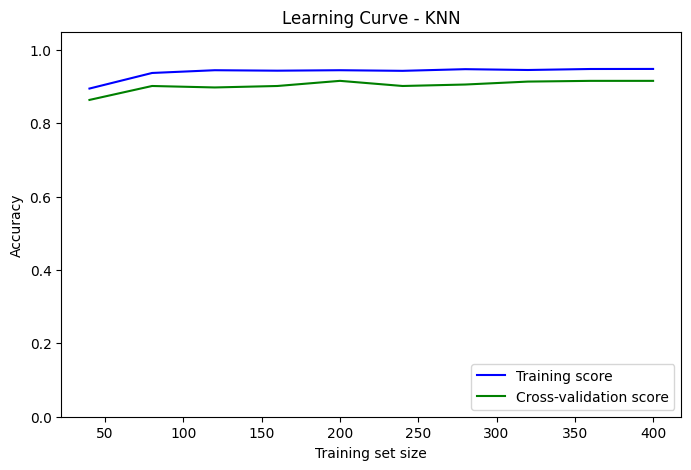

In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    pipeline, X, y, cv=N_SPLITS, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10), shuffle=True, random_state=RANDOM_STATE
)

# Media e deviazione standard
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)


# Grafico
plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, color='blue', label='Training score')
plt.plot(train_sizes, test_mean, color='green', label='Cross-validation score')
plt.title("Learning Curve - KNN")
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.ylim(0,1.05)
plt.legend(loc='lower right')
plt.show()

La linea blu indica le performance sul training set mentre quella verde sul test set. Il test score è in linea col training score questo fa pensare non ci siano problemi di overfitting. Le linee convergono con un'accuracy sopra allo 0.9.

###Validation curve

Permette di vedere come variano le performance del modello al variare di un iperparametro, nel nostro caso il numero di vicini (n_neighbors).

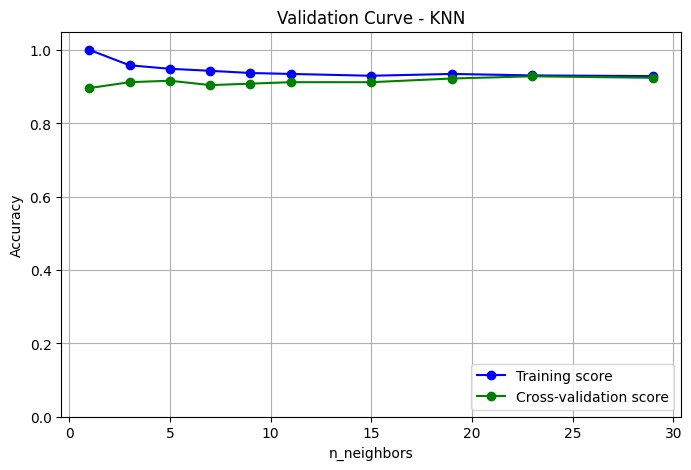

In [ ]:
# Calcolo la validation curve
train_scores, test_scores = validation_curve(
    pipeline,
    X, y,
    param_name="knn__n_neighbors",
    param_range=ks,
    cv=N_SPLITS,
    scoring="accuracy",
    n_jobs=-1
)

# Media e deviazione standard
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)


# Grafico
plt.figure(figsize=(8,5))
plt.plot(ks, train_mean, label="Training score", color="blue", marker='o')
plt.plot(ks, test_mean, label="Cross-validation score", color="green", marker='o')
plt.title("Validation Curve - KNN")
plt.xlabel("n_neighbors")
plt.ylabel("Accuracy")
plt.ylim(0,1.05)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

L’intersezione ottimale è dove il test score è massimo senza presenza di over fitting, ossia dove le due curve convergono. Il valore preso (20) è in linea con questa osservazione. Andando avanti le due curve tendono a divergere.

In [ ]:
#salvataggio del modello
joblib.dump(best_knn, "best_model.pkl")

['best_model.pkl']



##Conclusione

La rete realizzata si comporta molto bene sulle classi uva e banana, ha una lieve incertezza sulle classi mela, kiwi, arancia, comprensibile perchè anche un uomo ne avrebbe senza poter toccare i frutti o vedere il loro colore. Sarebbe interessante poter intrudorre altre feature come Colore o tipo di buccia (liscia/pelosa) questi indicatori potrebbero aiutare ad aumentare di molto l'accuracy perchè sono alcune delle feature principali che valuta anche il nostro cervello nel riconoscere un frutto (tramite vista e tatto).